## Model Training

Train 3 models and compare with 5-fold cross-validation.

**Models:**
- Ridge Regression — linear, simple baseline
- Random Forest — tree-based, handles non-linearity
- XGBoost — gradient boosting, usually best on tabular data

**Target:** log_price (reversed to euros for evaluation)

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_absolute_error, mean_squared_error
from xgboost                 import XGBRegressor
from pathlib                 import Path

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

# Load engineered data
DATA_DIR = Path('../../data/processed')

model_df = pd.read_parquet(DATA_DIR / 'model_ready.parquet')
#model_df = pd.read_parquet('../data/processed/model_ready.parquet')
with open(DATA_DIR / 'feature_list.json') as f:
    FEATURES = json.load(f)

X = model_df[FEATURES]
y = model_df['log_price']

print(f'Dataset  : {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'Target   : log_price (will reverse to euros for metrics)')
print(f'Price range: €{model_df["price"].min():.0f} – €{model_df["price"].max():.0f}')

Dataset  : 5,815 rows x 16 features
Target   : log_price (will reverse to euros for metrics)
Price range: €35 – €80018


In [54]:
# Define models
models = {
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10.0))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        base_score=0.5,
        random_state=42,
        verbosity=0
    ),
}

print('Model configurations:')
print('  Ridge Regression : linear model, L2 regularization, needs feature scaling')
print('  Random Forest    : 200 trees, max depth 12, handles non-linearity')
print('  XGBoost          : 400 boosting rounds, learning rate 0.05')

Model configurations:
  Ridge Regression : linear model, L2 regularization, needs feature scaling
  Random Forest    : 200 trees, max depth 12, handles non-linearity
  XGBoost          : 400 boosting rounds, learning rate 0.05


In [55]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.base import clone
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

print('Running 5-fold cross-validation...\n')

for name, model in models.items():

    print(f'Training {name}...')

    mae_scores, rmse_scores, mape_scores = [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # clone model for each fold (VERY IMPORTANT)
        m = clone(model)
        m.fit(X_train, y_train)

        y_pred_log = m.predict(X_val)

        # convert back to real price
        y_pred_real = np.expm1(y_pred_log)
        y_real = np.expm1(y_val)

        mae = mean_absolute_error(y_real, y_pred_real)
        rmse = np.sqrt(mean_squared_error(y_real, y_pred_real))

        epsilon = 1e-9
        mape = np.mean(np.abs((y_real - y_pred_real) / (y_real + epsilon))) * 100

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        mape_scores.append(mape)

    cv_results[name] = {
        'MAE_mean': np.mean(mae_scores),
        'MAE_std': np.std(mae_scores),
        'RMSE_mean': np.mean(rmse_scores),
        'RMSE_std': np.std(rmse_scores),
        'MAPE_mean': np.mean(mape_scores),
        'MAPE_std': np.std(mape_scores),
    }

    print(f'  MAE  = €{cv_results[name]["MAE_mean"]:.1f} ± {cv_results[name]["MAE_std"]:.1f}')
    print(f'  RMSE = €{cv_results[name]["RMSE_mean"]:.1f} ± {cv_results[name]["RMSE_std"]:.1f}')
    print(f'  MAPE = {cv_results[name]["MAPE_mean"]:.1f}% ± {cv_results[name]["MAPE_std"]:.1f}%\n')

print('Cross-validation complete.')

Running 5-fold cross-validation...

Training Ridge Regression...
  MAE  = €158.5 ± 62.8
  RMSE = €1605.3 ± 1212.3
  MAPE = 32.0% ± 0.9%

Training Random Forest...
  MAE  = €152.1 ± 60.4
  RMSE = €1584.2 ± 1202.4
  MAPE = 30.7% ± 1.3%

Training XGBoost...
  MAE  = €145.5 ± 51.8
  RMSE = €1485.9 ± 1085.8
  MAPE = 31.0% ± 1.4%

Cross-validation complete.


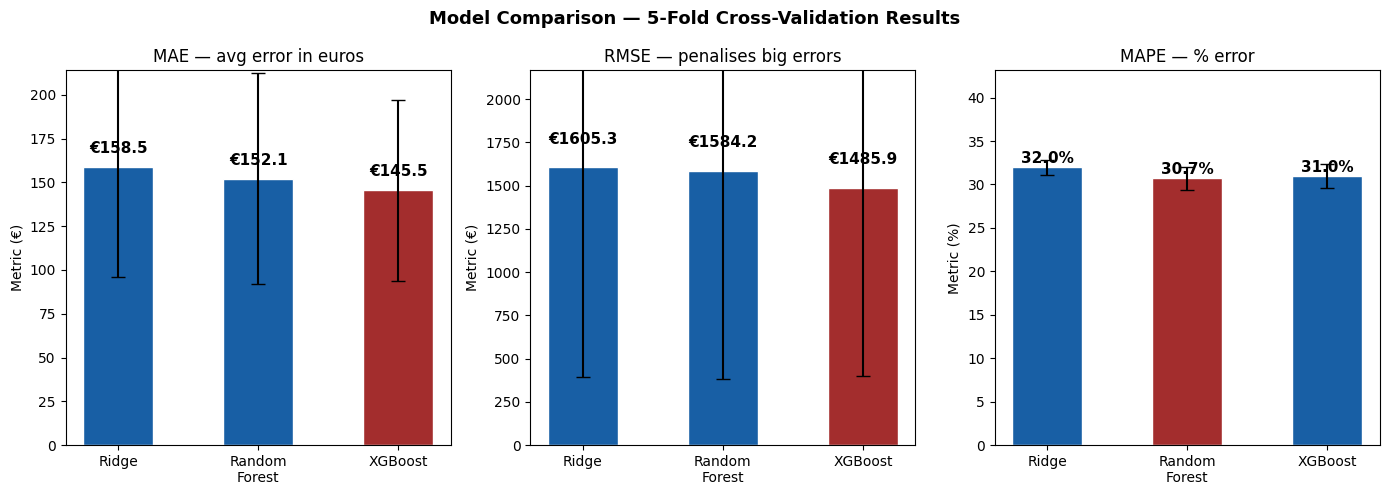

Best model: XGBoost  (MAE = €145.5)

Interpretation: On average, XGBoost predicts nightly price
within €145 of the actual price.


In [56]:
# Results comparison chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Comparison — 5-Fold Cross-Validation Results',
             fontsize=13, fontweight='bold')

model_names  = list(cv_results.keys())
short_names  = ['Ridge', 'Random\nForest', 'XGBoost']

for ax, (metric_mean, metric_std, title, unit) in zip(axes, [
    ('MAE_mean',  'MAE_std',  'MAE — avg error in euros',  '€'),
    ('RMSE_mean', 'RMSE_std', 'RMSE — penalises big errors', '€'),
    ('MAPE_mean', 'MAPE_std', 'MAPE — % error',             '%'),
]):
    vals  = [cv_results[m][metric_mean] for m in model_names]
    stds  = [cv_results[m][metric_std]  for m in model_names]
    best  = np.argmin(vals)
    cols  = ['#A32D2D' if i == best else '#185FA5' for i in range(len(vals))]

    bars = ax.bar(short_names, vals, color=cols,
                  edgecolor='white', width=0.5, yerr=stds,
                  capsize=5, error_kw={'linewidth': 1.5})
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(stds) * 0.1,
                f'{unit}{val:.1f}' if unit == '€' else f'{val:.1f}{unit}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(title)
    ax.set_ylabel(f'Metric ({unit})')
    ax.set_ylim(0, max(vals) * 1.35)

plt.tight_layout()
plt.savefig('../../reports/fig_ml_model_comparison.png',
            dpi=130, bbox_inches='tight')
plt.show()

best_model = min(cv_results, key=lambda x: cv_results[x]['MAE_mean'])
best_mae   = cv_results[best_model]['MAE_mean']
print(f'Best model: {best_model}  (MAE = €{best_mae:.1f})')
print(f'\nInterpretation: On average, {best_model} predicts nightly price')
print(f'within €{best_mae:.0f} of the actual price.')

In [57]:
# Train final models on FULL dataset and save
print('Training final models on full dataset and saving...')

for name, model in models.items():
    model.fit(X, y)
    filename = name.lower().replace(' ', '_') + '.pkl'
    with open(MODELS_DIR / filename, 'wb') as f:
        pickle.dump(model, f)
    print(f'  Saved {filename}')

# Save CV results
cv_df = pd.DataFrame(cv_results).T.round(2)
cv_df.to_csv('../../data/processed/cv_results.csv')
print('\nCV results saved to ml/data/cv_results.csv')
print('\nAll models saved to ml/models/')

Training final models on full dataset and saving...
  Saved ridge_regression.pkl
  Saved random_forest.pkl
  Saved xgboost.pkl

CV results saved to ml/data/cv_results.csv

All models saved to ml/models/


In [58]:
# Check for any features that might leak price
suspicious = [f for f in FEATURES if 'price' in f.lower() or 'revenue' in f.lower()]
print('Potentially leaking features:', suspicious)

Potentially leaking features: []


In [59]:
print(f'y dtype      : {y.dtype}')
print(f'y min        : {y.min():.4f}')
print(f'y max        : {y.max():.4f}')
print(f'y sample     : {y.head(5).tolist()}')
print(f'expm1 sample : {np.expm1(y.head(5)).tolist()}')

y dtype      : float64
y min        : 3.5835
y max        : 11.2900
y sample     : [4.890349128221754, 4.499809670330265, 4.127134385045092, 5.777652323222656, 6.126869184114185]
expm1 sample : [132.0, 89.0, 61.00000000000001, 321.99999999999994, 457.00000000000017]


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Features and target
X = model_df[FEATURES]
y = model_df["log_price"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train the best model
best_model = XGBRegressor(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

best_model.fit(X_train, y_train)

# Predictions (log scale)
train_pred_log = best_model.predict(X_train)
test_pred_log = best_model.predict(X_test)

# Convert back to price
train_pred = np.expm1(train_pred_log)
test_pred = np.expm1(test_pred_log)

train_actual = np.expm1(y_train)
test_actual = np.expm1(y_test)

# Metrics
train_mae = mean_absolute_error(train_actual, train_pred)
test_mae = mean_absolute_error(test_actual, test_pred)

train_rmse = np.sqrt(mean_squared_error(train_actual, train_pred))
test_rmse = np.sqrt(mean_squared_error(test_actual, test_pred))

train_r2 = r2_score(train_actual, train_pred)
test_r2 = r2_score(test_actual, test_pred)

print("===== Training =====")
print(f"MAE : €{train_mae:.2f}")
print(f"RMSE: €{train_rmse:.2f}")
print(f"R²  : {train_r2:.3f}")

print("\n===== Testing =====")
print(f"MAE : €{test_mae:.2f}")
print(f"RMSE: €{test_rmse:.2f}")
print(f"R²  : {test_r2:.3f}")

===== Training =====
MAE : €87.72
RMSE: €1231.13
R²  : 0.617

===== Testing =====
MAE : €151.37
RMSE: €1606.11
R²  : 0.370
